In [1]:
%reset -f

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unicodedata import normalize
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset,DataLoader
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import torch 
import re 
import os

## Funciones

In [3]:
# Limpiar texto
def limpiar_texto(texto: str):
    texto_1 = re.sub(
        r"([^n\u0300-\u036f]|n(?!\u0303(?![\u0300-\u036f])))[\u0300-\u036f]+", r"\1",
        normalize('NFD', texto), 0, re.I
    )
    texto_2 = normalize('NFC', texto_1)
    return texto_2.lower().strip().replace(' ', '_')

## Cargue de datos

In [4]:
os.chdir(r"C:\Users\jeosp\OneDrive\Desktop\Principal\Maestría\deep_learning\data")

# Cargar expectativas de inflación 
expectativas = pd.read_excel('Expectativas de inflación.xlsx', sheet_name = 'INFLACION_TOTAL')

# Cargar tasa de interes de política monetaria 
tasa_politica = pd.read_excel('Tasas de interés de política monetaria.xlsx', sheet_name = 'Datos')

# Cargar IPC 
indices_precios = pd.read_excel('IPC.xlsx', sheet_name = 'Series de datos')

# Cargar tasa IBR
tasa_ibr = pd.read_excel('Tasas de interés.xlsx', sheet_name = 'Datos')

# Cargar TRM
tasa_mercado = pd.read_excel('Tasa de cambio del peso colombiano.xlsx', sheet_name = 'Datos')

## Limpieza de datos
### Expectativas

In [5]:
# Seleccionar columnas a emplear 
expectativas = expectativas.iloc[:, [0, 6]]

# Definir nombre de columnas
expectativas.columns = expectativas.loc[0, :]

# Limpiar nombre de columnas 
expectativas.columns = [limpiar_texto(col) for col in expectativas.columns]

# Filtrar filas sobrantes 
expectativas = expectativas.loc[2:, :].reset_index(drop = True)

# Pasar datos a su formato correcto
print(expectativas.dtypes)
expectativas['fecha_encuesta'] = pd.to_datetime(expectativas['fecha_encuesta'], yearfirst = True,
                                                format = '%Y/%m/%d', errors = 'raise')
expectativas['mediana'] = expectativas['mediana'].astype(float)
print(expectativas.dtypes)

fecha_encuesta    object
mediana           object
dtype: object
fecha_encuesta    datetime64[us]
mediana                  float64
dtype: object


C:\Users\jeosp\AppData\Local\Temp\ipykernel_13168\2590358663.py:3: DeprecationWarning: 'count' is passed as positional argument
  texto_1 = re.sub(


### Tasa de política

In [6]:
# Limpiar nombres de columnas
tasa_politica.columns = [limpiar_texto(col) for col in tasa_politica.columns]

# Eliminar filas inecesarias
mascara = (tasa_politica['fecha'].isna() & tasa_politica['fecha'].shift().notna())
indice_final = tasa_politica.index[mascara][0]
tasa_politica = tasa_politica.iloc[1:indice_final, :]

# Transformar los tipos de datos 
tasa_politica['fecha'] = pd.to_datetime(tasa_politica['fecha'], yearfirst = True, format = '%Y/%m/%d',
                                        errors = 'raise')
tasa_politica['tasa_de_politica_monetaria'] = tasa_politica['tasa_de_politica_monetaria'] / 100
tasa_politica['tasa_de_politica_monetaria'] = tasa_politica['tasa_de_politica_monetaria'].astype(float)

C:\Users\jeosp\AppData\Local\Temp\ipykernel_13168\2590358663.py:3: DeprecationWarning: 'count' is passed as positional argument
  texto_1 = re.sub(


### Indice de precios al consumidor

In [7]:
# Limpiar nombres de columnas
indices_precios.columns = [limpiar_texto(col) for col in indices_precios.columns]

# Seleccionar columnas 
indices_precios = indices_precios.iloc[:, [0, 1]]

# Filtrar filas 
mascara = (indices_precios['ipc_nucleo_15'].isna() & indices_precios['ipc_nucleo_15'].shift().notna())
indice_final = indices_precios.index[mascara][0]
indices_precios = indices_precios.iloc[:indice_final, :]

# Transformar datos
indices_precios['fecha'] = pd.to_datetime(indices_precios['fecha'], yearfirst = True, format = '%Y/%m/%d', errors = 'raise')
indices_precios['ipc_nucleo_15'] = indices_precios['ipc_nucleo_15'].astype(float)

C:\Users\jeosp\AppData\Local\Temp\ipykernel_13168\2590358663.py:3: DeprecationWarning: 'count' is passed as positional argument
  texto_1 = re.sub(


### Tasa IBR

In [8]:
# Limpiar columnas 
tasa_ibr.columns = [limpiar_texto(col) for col in tasa_ibr.columns]

# Filtrar columns y filas 
mascara = (
    tasa_ibr['indicador_bancario_de_referencia_(ibr)_overnight,_nominal'].isna() &
    tasa_ibr['indicador_bancario_de_referencia_(ibr)_overnight,_nominal'].shift().notna()
)

indice_final = tasa_ibr.index[mascara][0]
tasa_ibr = tasa_ibr.iloc[1:indice_final, [0, 1]].reset_index(drop = True)
tasa_ibr.columns = ['fecha', 'ibr_overnight']

# Transformar datos
tasa_ibr['fecha'] = pd.to_datetime(tasa_ibr['fecha'], yearfirst = True, errors = 'raise', format = '%Y/%m/%d')
tasa_ibr['ibr_overnight'] = tasa_ibr['ibr_overnight'].astype(float) / 100

C:\Users\jeosp\AppData\Local\Temp\ipykernel_13168\2590358663.py:3: DeprecationWarning: 'count' is passed as positional argument
  texto_1 = re.sub(


### Tasa representativa de mercado

In [9]:
tasa_mercado.columns = [limpiar_texto(col) for col in tasa_mercado.columns]

# Eliminar filas inecesarias 
mascara = (tasa_mercado['tasa_representativa_del_mercado_(trm)'].isna() &
           tasa_mercado['tasa_representativa_del_mercado_(trm)'].shift().notna())
indice_final = tasa_mercado.index[mascara][0]

tasa_mercado = tasa_mercado.iloc[1:indice_final, :].reset_index(drop = True)

# transformar datos
tasa_mercado['fecha'] = pd.to_datetime(tasa_mercado['fecha'], yearfirst = True, format = '%Y/%m/%d', errors = 'raise')
tasa_mercado['tasa_representativa_del_mercado_(trm)'] = tasa_mercado['tasa_representativa_del_mercado_(trm)'].astype(float)
tasa_mercado.columns = ['fecha', 'trm']

C:\Users\jeosp\AppData\Local\Temp\ipykernel_13168\2590358663.py:3: DeprecationWarning: 'count' is passed as positional argument
  texto_1 = re.sub(


## Seleccionar el mismo horizonte temporal para todas las variables

In [10]:
limite_inferior = datetime.strptime('2008/01/01', '%Y/%m/%d')
limite_superior = datetime.strptime('2026/04/30', '%Y/%m/%d')

mascara_expectativas = (
    (limite_inferior <= expectativas['fecha_encuesta']) &
    (expectativas['fecha_encuesta'] <= limite_superior)
)

mascara_tasa_politica = (
    (limite_inferior <= tasa_politica['fecha']) &
    (tasa_politica['fecha'] <= limite_superior)
)

mascara_indice_precios = (
    (limite_inferior <= indices_precios['fecha']) &
    (indices_precios['fecha'] <= limite_superior)
)

mascara_ibr = (
    (limite_inferior <= tasa_ibr['fecha']) &
    (tasa_ibr['fecha'] <= limite_superior)
)

mascara_trm = (
    (limite_inferior <= tasa_mercado['fecha']) &
    (tasa_mercado['fecha'] <= limite_superior)
)

expectativas = expectativas[mascara_expectativas]
tasa_politica = tasa_politica[mascara_tasa_politica]
indices_precios = indices_precios[mascara_indice_precios]
tasa_ibr = tasa_ibr[mascara_ibr]
tasa_mercado = tasa_mercado[mascara_trm]


In [11]:
# De las variables tomar solo el ultimo dato de cada mes 
expectativas = expectativas.resample('MS', on = 'fecha_encuesta').last()
indices_precios = indices_precios.resample('MS', on = 'fecha').last()
tasa_politica = tasa_politica.resample('MS', on = 'fecha').last()
tasa_ibr = tasa_ibr.resample('MS', on = 'fecha').last()
tasa_mercado = tasa_mercado.resample('MS', on = 'fecha').last()

In [12]:
df_modelo = pd.DataFrame({
    'fecha': pd.date_range(start = limite_inferior, end = limite_superior, freq = 'ME'),
    'expectativas': expectativas['mediana'],
    'tasa_politica': tasa_politica['tasa_de_politica_monetaria'],
    'indices_precios': indices_precios['ipc_nucleo_15'],
    'tasa_ibr': tasa_ibr['ibr_overnight'],
    'tasa_mercado': tasa_mercado['trm']
})

df_modelo['indices_precios'] = df_modelo['indices_precios'].fillna(df_modelo['indices_precios'].mean())

<Axes: xlabel='fecha', ylabel='indices_precios'>

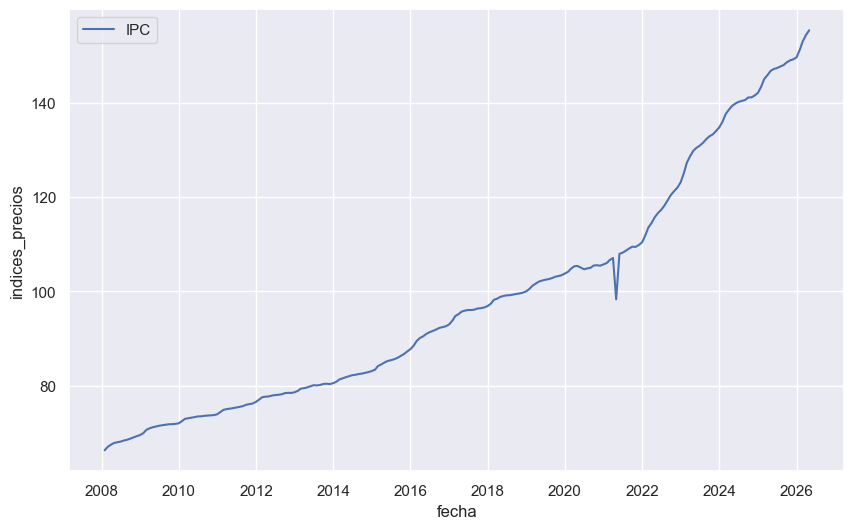

In [ ]:
sns.set_theme(style = 'darkgrid')
fig, ax = plt.subplots(figsize = (10, 6))
sns.lineplot(data = df_modelo, x = 'fecha', y = 'indices_precios', ax = ax, label = 'IPC')

Text(0, 0.5, 'Porcentaje (%)')

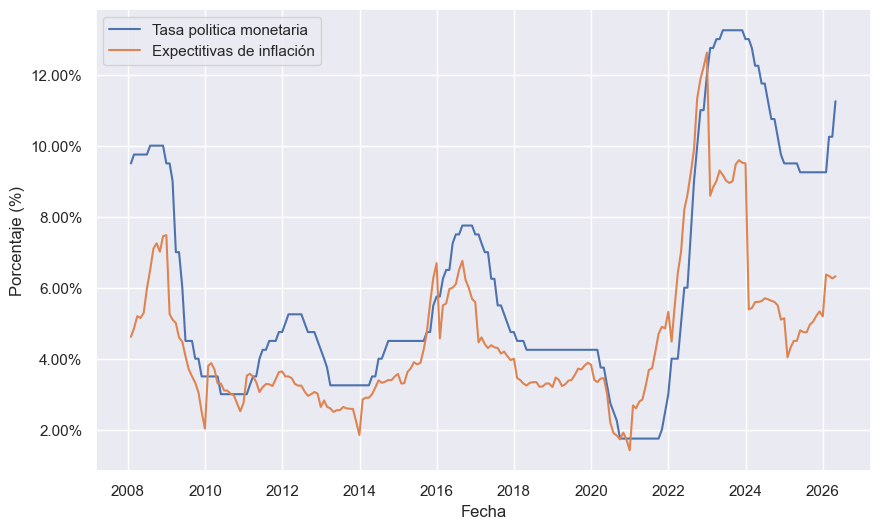

In [31]:
sns.set_theme(style = 'darkgrid')
fig, ax = plt.subplots(figsize = (10, 6))
sns.lineplot(data = df_modelo, x = 'fecha', y = 'tasa_politica', ax = ax, label = 'Tasa politica monetaria')
sns.lineplot(data = df_modelo, x = 'fecha', y = 'expectativas', ax = ax, label = 'Expectitivas de inflación')
ax.yaxis.set_major_formatter(PercentFormatter(xmax = 1, decimals = 2))
ax.set_xlabel('Fecha')
ax.set_ylabel('Porcentaje (%)')

Text(0, 0.5, 'Monto (COP)')

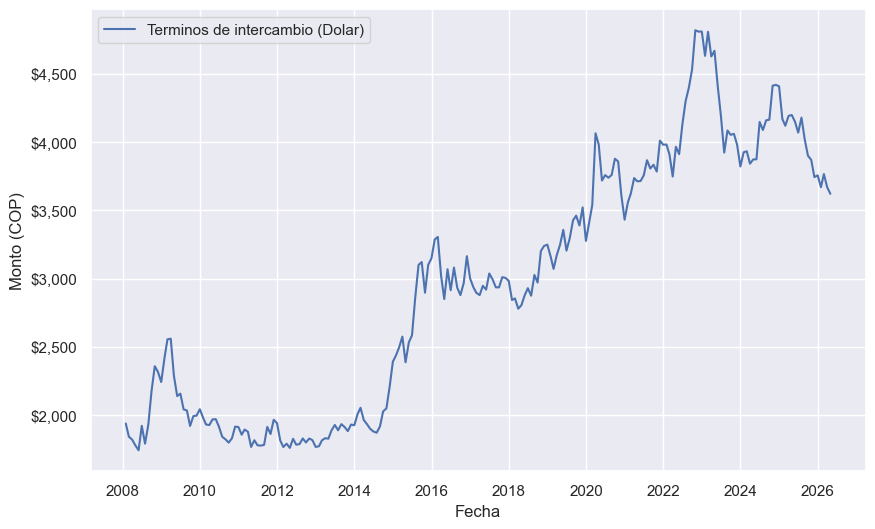

In [34]:
sns.set_theme(style = 'darkgrid')
fig, ax = plt.subplots(figsize = (10, 6))
sns.lineplot(data = df_modelo, x = 'fecha', y = 'tasa_mercado', ax = ax, label = 'Terminos de intercambio (Dolar)')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('Fecha')
ax.set_ylabel('Monto (COP)')